**Using PINNs to find out how long it takes for a beer (or non-alcoholic, for those who prefer so :)) bottle to cool down in a fridge**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [ ]:
# Modelling the bottle as an infinitely long (not true, but whatever, I want to stick to 2 spatial dimensions) cylinder of radius R
# the bottle is originally at 22 degrees
# It sits in the fridge with no convective heat trasnfer, just constant temperature at the boundary (4 C)
# Goal: understand when the average temperature of the bottle cools down to a target temperature (say 6 C)
# simple heat equation with Dirichlet boundary conditions, no recirculations inside the bottle

bottle_radius = 0.02
alpha_water = 0.133e-6 #m2/s thermal diffusivity of water

#strategy: solve for alpha = 1. then rescale t -> t / alpha_water in the solution
bottle_pinn = PINN_heat_2d_circle(N_internal_nodes=16, f_initial=lambda x: 22, f_dirichlet=lambda x: 4, R=bottle_radius, t_bounds=(0,0.025), alpha = 1)
bottle_pinn.set_collocation_points(3000)
bottle_pinn.compute_initial_values(1000, 0)
bottle_pinn.compute_boundary_values(2000)
bottle_pinn.compute_physics_loss()

bottle_pinn.train_RAD(weight_bdy=100)

Epoch [1000/30000], N_collocation_points: 3300, Loss: 2945.4556
Epoch [2000/30000], N_collocation_points: 3700, Loss: 2945.4546
Epoch [3000/30000], N_collocation_points: 4100, Loss: 2945.4534
Epoch [4000/30000], N_collocation_points: 4500, Loss: 2945.1858
Epoch [5000/30000], N_collocation_points: 4900, Loss: 2945.4546
Epoch [6000/30000], N_collocation_points: 5300, Loss: 2945.4543
Epoch [7000/30000], N_collocation_points: 5700, Loss: 2945.4541
Epoch [8000/30000], N_collocation_points: 6100, Loss: 2945.4531
Epoch [9000/30000], N_collocation_points: 6500, Loss: 2945.3423
Epoch [10000/30000], N_collocation_points: 6900, Loss: 2945.4753
Epoch [11000/30000], N_collocation_points: 7300, Loss: 2945.4619
Epoch [12000/30000], N_collocation_points: 7700, Loss: 2945.4648
Epoch [13000/30000], N_collocation_points: 8100, Loss: 2945.4536
Epoch [14000/30000], N_collocation_points: 8500, Loss: 2945.4543
Epoch [15000/30000], N_collocation_points: 8900, Loss: 2945.4541
Epoch [16000/30000], N_collocation

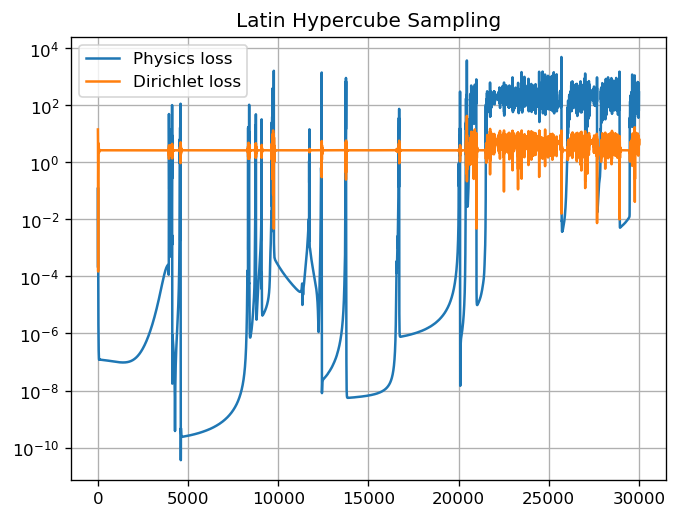

In [12]:

plt.figure(dpi= 120)
plt.title('Latin Hypercube Sampling')
plt.semilogy(bottle_pinn.physics_losses, label = "Physics loss")
plt.semilogy(bottle_pinn.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_21736/1763721147.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')


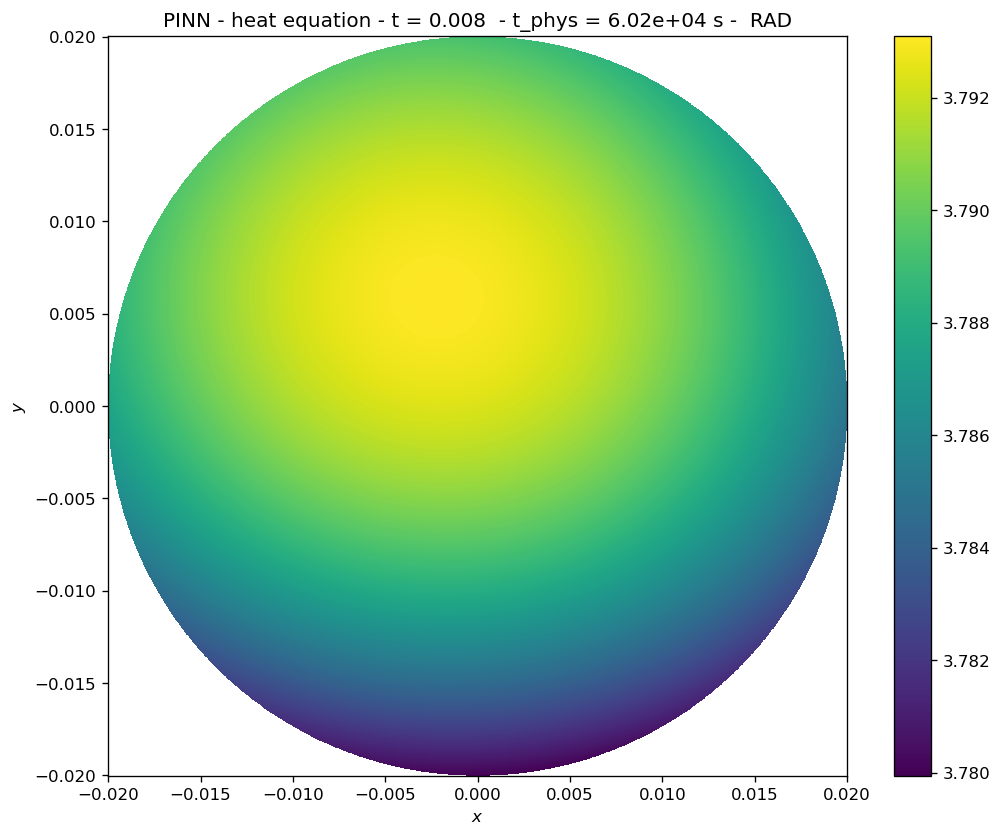

In [13]:
radius = 0.02
t_check = 0.008

N_r, N_theta = 1000, 2000
r = np.linspace(0, radius, N_r)
theta = np.linspace(0, 2*np.pi, N_theta)
R, Theta = np.meshgrid(r, theta)  # both shape (N_theta, N_r)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = bottle_pinn.model(grid_points_torch)  # shape (N_theta*N_r, 1)

res = u_pred.numpy().reshape(X.shape)  # back to (N_theta, N_r) to match X, Y grid

fig, ax = plt.subplots(figsize=(10, 8), dpi = 120)
#pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto', vmin=4, vmax=20)
pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax)
ax.set_title(f'PINN - heat equation - t = {t_check}  - t_phys = {t_check/alpha_water:.3g} s -  RAD')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()

STUFF TO DO/PROBLEMS TO FIX

convergence slow. when I train on small times (which is the range I am interested in) even worse, converges often to the trivial solution

also, difficult to see a nice gradient on the boundary. tried raising the boundary weight to 100 (from 10), did not really work. 

plus the cooling down seems a bit slow, compared to experience. should need to check with my next beer :)


gradient-norm balancing: see https://arxiv.org/pdf/2001.04536


## Reparametrisation/hard constraint

*the solution converges too often to the trivial solution, and gets stuck. Try another way*

So I define the solution as 

$T(x,y,z) = A(t) + D(x,y)t N(x,y,t)$

where $N(x,y,t)$ is the function to "solve" for.

I use:
$A(t) = T_{in} \, e^{-t/\tau} + T_{bdy} \,(1 - e^{-t/\tau})$

$D(x,y) = R^2 - x^2 - y^2$

The initial and boundary conditions are then automatically satisfied, provided $\tau$ is small enough.

After computing all derivaties the heat equation becomes: 

$\frac{(T_{bdy} -T_{in} )}{\tau}\,e^{-t/\tau} + (R^2 - x^2 - y^2)N + t \,(R^2 - x^2 - y^2)\, \partial_t N + \alpha \, t \, \big( 4N + 4x \, \partial_x N + 4y \, \partial_y N - (R^2 -x^2 - y^2)\, \Delta N\big) = 0$ 

(this last equation is purely pedagogical, in the code I define $T = A + D\,t\,N$ and let autograd do the differentiations)

We work with N in our PINN.

see for instance:
Lagaris, I. E., Likas, A., & Fotiadis, D. I. (1998). "Artificial Neural Networks for Solving Ordinary and Partial Differential Equations." IEEE Transactions on Neural Networks, 9(5), 987–1000

Sukumar, N., & Srivastava, A. (2022). "Exact imposition of boundary conditions with distance functions in physics-informed deep neural networks." Computer Methods in Applied Mechanics and Engineering, 389, 114333.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

bottle_radius = 0.02
alpha_water = 0.133e-6 #m2/s thermal diffusivity of water
final_time = 2*3600. # two hours
R_bottle = 0.02 # in meters
alpha_eq = alpha_water*final_time/R_bottle**2 # reparametrization
alpha_eq = 1. # reparametrization
print(alpha_eq)

1.0


In [36]:
#strategy: solve for alpha = 1. then rescale t -> t / alpha_water in the solution
bottle_pinn = PINN_heat_2d_circle_reparametrised(N_internal_nodes=16, f_initial=lambda x: 22, f_dirichlet=lambda x: 4, t_bounds=(0,1), tau = 1./10, alpha = alpha_eq)
bottle_pinn.set_collocation_points(3000)
bottle_pinn.compute_physics_loss()

bottle_pinn.train_RAD(max_epochs = 50000)

Epoch [1000/50000], N_collocation_points: 3000, Loss: 372.5223
Epoch [2000/50000], N_collocation_points: 3000, Loss: 185.7900
Epoch [3000/50000], N_collocation_points: 3000, Loss: 128.1556
Epoch [4000/50000], N_collocation_points: 3000, Loss: 94.5176


KeyboardInterrupt: 

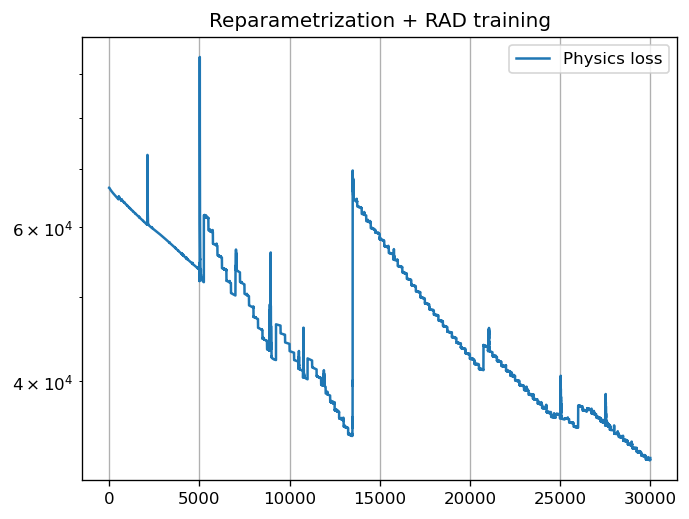

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_27402/3239571208.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')


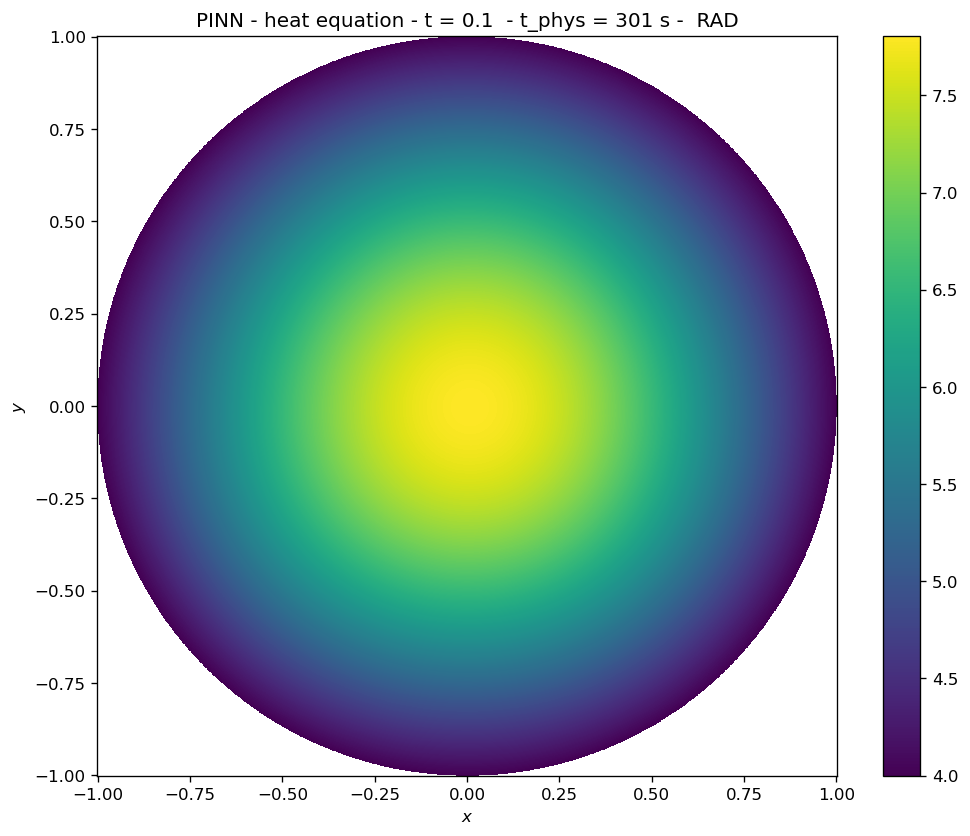

In [10]:
plt.figure(dpi= 120)
plt.title('Reparametrization + RAD training')
plt.semilogy(bottle_pinn.physics_losses, label = "Physics loss")
plt.grid(True)
plt.legend()
plt.show()



radius = 1.
t_check = 0.1

N_r, N_theta = 1000, 2000
r = np.linspace(0, radius, N_r)
theta = np.linspace(0, 2*np.pi, N_theta)
R, Theta = np.meshgrid(r, theta)  # both shape (N_theta, N_r)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = bottle_pinn.forward(grid_points_torch)  # shape (N_theta*N_r, 1)

res = u_pred.numpy().reshape(X.shape)  # back to (N_theta, N_r) to match X, Y grid

fig, ax = plt.subplots(figsize=(10, 8), dpi = 120)
pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax)
ax.set_title(f'PINN - heat equation - t = {t_check}  - t_phys = {t_check/alpha_water*R_bottle**2:.3g} s -  RAD')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()

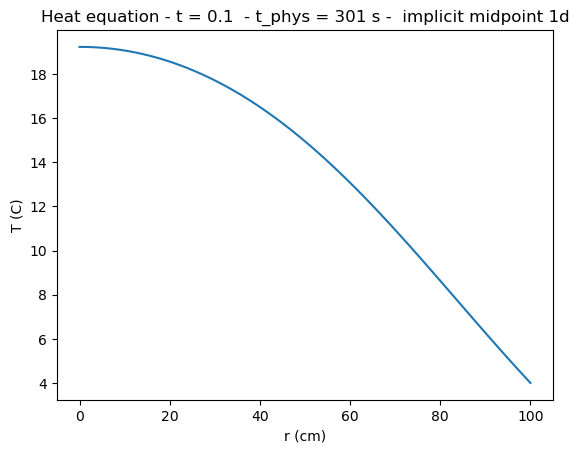

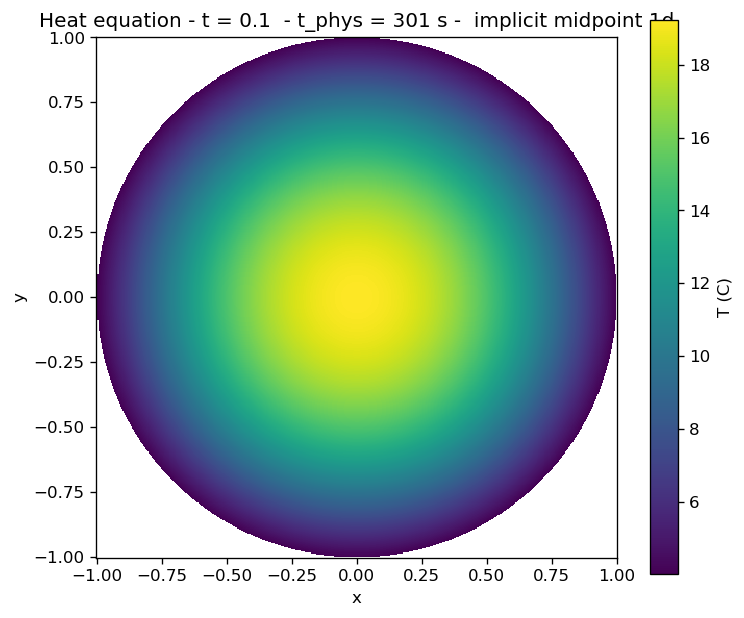

In [43]:
"""reduce to a one-variable problem (red) and solve with finite difference and the implicit midpoint rule in time"""


import scipy.sparse as sp

# in polar coordinates if there is no theta dependence Delta f =  1/r d_r f + d_r^2 f
# solve this in 1d to have a reference solution

initial_temperature = 22.
boundary_temperature = 4.
bdy_temperature = 4.
N = 100  # Number of spatial grid points
L = 0.02  # Domain size
L = 1.
final_time = 0.0001
final_time = 0.1
N_t = 100
xx, dx = np.linspace(0, L , N, retstep = True) # discretization size (in r)
times, dt = np.linspace(0, final_time, N_t,retstep=True)
alpha_water = 0.133e-6 
alpha_eq = 1.

# first derivative matrix
diagonals_1st = [-np.ones(N), np.ones(N)]
offsets_1st = [-1, 1]
D1 = sp.diags(diagonals_1st, offsets_1st, shape=(N, N), format='csr') / (2 * dx)
diagonals = [np.ones(N), -2 * np.ones(N), np.ones(N)]
offsets = [-1, 0, 1]
# second derivative matrix
D2 = sp.diags(diagonals, offsets, shape=(N, N), format='csr') / (dx**2)

#now build the laplacian matrix
one_over_r = sp.diags(1./xx[1:])
laplacian = D2
laplacian[1:, 0:] += one_over_r.dot(D1[1:, 0:])
# the following line would be needed if we wanted to have the laplacian; but it would not the needed in the matrix we are going to use, anyways
# this is because we are replacing it by the boundary condition f'(r=0) = 0 (symmetry)
# laplacian[0, :] += laplacian[0, :] # by the l'hopital rule in the r->0 limit 1/r d_r f = d_r^2 f
M = sp.diags(np.ones(N)) - 0.5 * dt * laplacian * alpha_eq
# boundary conditions:
M[0,0] = 1; M[0,1] = -1; M[0,2:] = 0
M[-1,:] = 0; M[-1,-1] = 1

initial_solution = initial_temperature*np.ones(N)
solution = initial_solution.copy()

for kt in range(N_t):
    rhs = solution + alpha_eq* 0.5 * dt * laplacian.dot(solution)
    # boundary conditions
    rhs[0] = 0
    rhs[-1] = boundary_temperature
    solution = spsolve(M, rhs)


plt.figure()
plt.xlabel("r (cm)")
plt.ylabel("T (C)")
plt.plot(100*xx,solution)
plt.title(f'Heat equation - t = {final_time}  - t_phys = {final_time/(alpha_water)*R_bottle**2:.3g} s -  implicit midpoint 1d')
plt.show()

r_values = xx
u_values = solution
R = r_values.max()  # domain radius
# build a 2D Cartesian grid
N_grid = 500
x = np.linspace(-R, R, N_grid)
y = np.linspace(-R, R, N_grid)
X, Y = np.meshgrid(x, y)
Rgrid = np.sqrt(X**2 + Y**2)

# interpolate u(r) onto the grid; mask points outside the disk
U = np.interp(Rgrid, r_values, u_values)
U[Rgrid > R] = np.nan  # blank out the region outside the circle

fig, ax = plt.subplots(dpi=120,figsize=(7, 6))
pcm = ax.pcolormesh(X, Y, U, cmap='viridis', shading='auto')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax, label='T (C)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Heat equation - t = {final_time}  - t_phys = {final_time/(alpha_water)*R_bottle**2:.3g} s -  implicit midpoint 1d')
plt.show()

In [41]:
#  TESTS TO DO: PLOT PINN RESULTS ALONG DIFFERENT ANGLES TO SEE ANGLES VARIABILITY, COMPARE WITH 1D FINITE DIFF SOLUTION